# 1 Creating and Manipulating Arrays

In [1]:
import numpy as np
from matplotlib import pyplot as plt

### 1.1. Create two 2D arrays representing coordinates x, y on the cartesian plan

In [2]:
x1d = np.linspace(-2, 2, 100)
y1d = np.linspace(-2, 2, 100)

x, y = np.meshgrid(x1d, y1d)

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (100, 100)
y shape: (100, 100)


### 1.2. Visualize each 2D array using pcolormesh

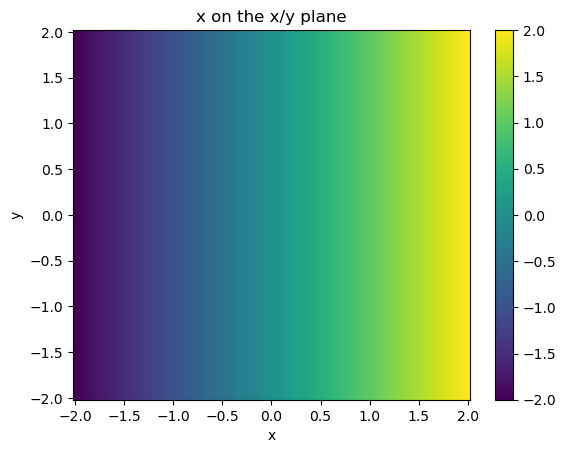

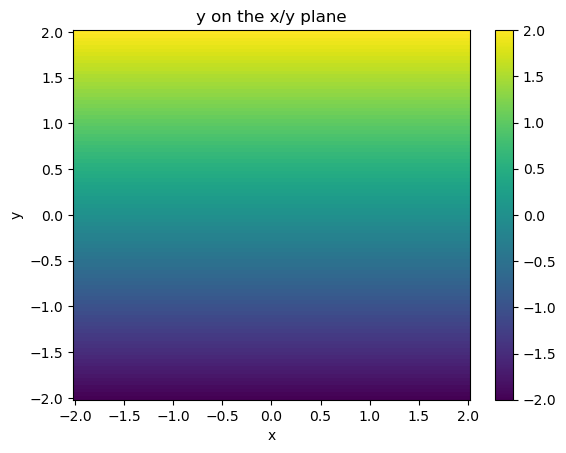

In [3]:
plt.pcolormesh(x1d, y1d, x)
plt.colorbar()
plt.title("x on the x/y plane")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

plt.pcolormesh(x1d, y1d, y)
plt.colorbar()
plt.title("y on the x/y plane")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### 1.3 From your cartesian coordinates, create polar coordinates $r$ and $\varphi$


In [4]:
r = np.sqrt(x**2 + y**2)
phi = np.arctan2(y, x)

print("r shape:", r.shape)
print("phi shape:", phi.shape)

r shape: (100, 100)
phi shape: (100, 100)


### 1.4. Visualize $r$ and $\varphi$ on the 2D $x$ / $y$ plane using pcolormesh

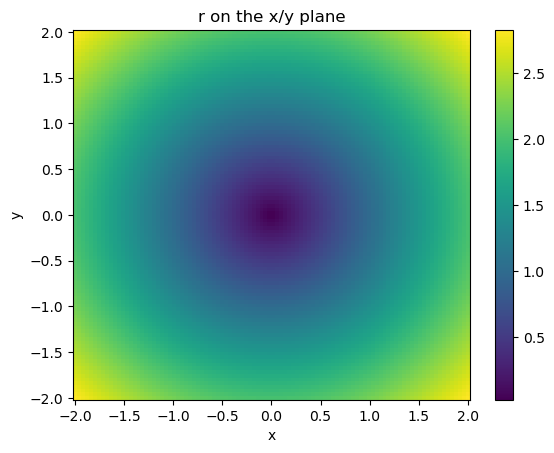

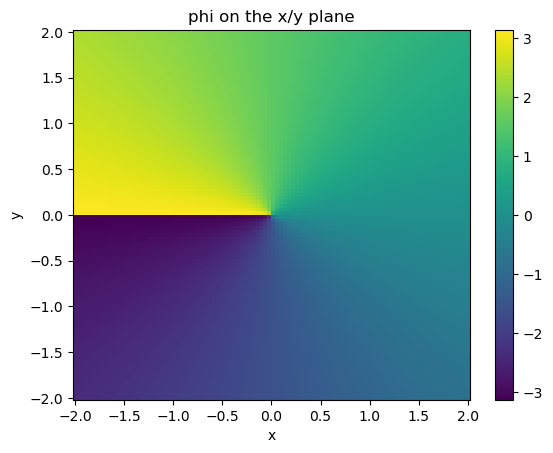

In [5]:
plt.pcolormesh(x1d, y1d, r)
plt.colorbar()
plt.title("r on the x/y plane")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

plt.pcolormesh(x1d, y1d, phi)
plt.colorbar()
plt.title("phi on the x/y plane")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### 1.5 Caclulate the quanity $ f = cos^2(4r) + sin^2(4\varphi)$

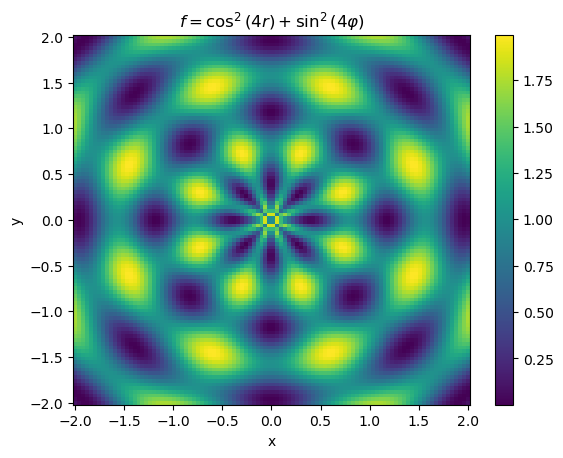

In [6]:
f = (np.cos(4*r)**2) + (np.sin(4*phi)**2)

plt.pcolormesh(x1d, y1d, f)
plt.colorbar()
plt.title(r"$f=\cos^2(4r)+\sin^2(4\varphi)$")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Part 2: Analyze ARGO Data

In [7]:
import pooch
url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash="2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009")
files

['/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

### 2.1 Load each data file as a numpy array.


In [8]:
T = np.load('/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy')
S = np.load('/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy')
P = np.load('/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy')
date = np.load('/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy')
lat = np.load('/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy')
lon = np.load('/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy')
level = np.load('/home/xg2467/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy')

print("T shape:", T.shape)
print("S shape:", S.shape)
print("P shape:", P.shape)
print("date shape:", date.shape)
print("lat shape:", lat.shape)
print("lon shape:", lon.shape)
print("level shape:", level.shape)

T shape: (78, 75)
S shape: (78, 75)
P shape: (78, 75)
date shape: (75,)
lat shape: (75,)
lon shape: (75,)
level shape: (78,)


### 2.2 Examine the shapes of T, S and P compared to lon, lat, date and level. How do you think they are related?

date, lat, and lon all have shape (75,), meaning there are 75 individual profiles, and each profile has one associated date and geographic location. level has shape (78,), meaning each profile is sampled at 78 depth (pressure) levels. T, S, and P each have shape (78, 75), so they vary across both depth and profile number: the first dimension corresponds to level (78), and the second dimension corresponds to profiles (75). Therefore, T, S, and P share the same two dimensions (levels × profiles), while date/lat/lon align only with the profiles dimension.

### 2.3 Make a plot for each column of data in T, S and P (three plots).

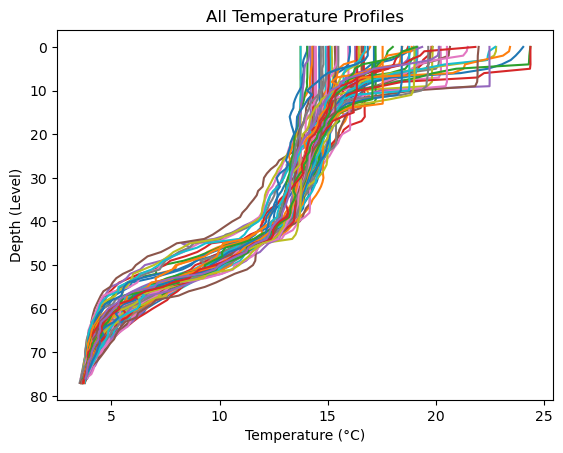

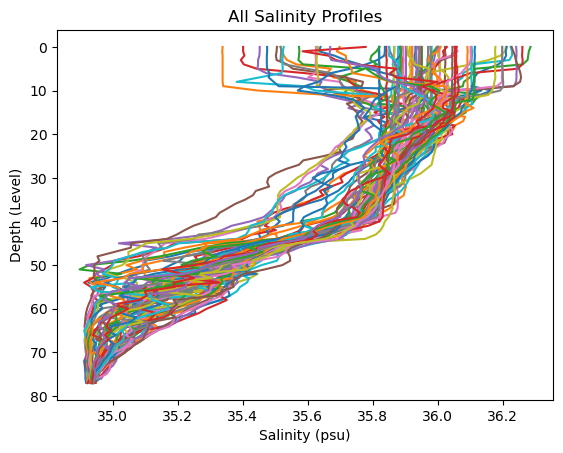

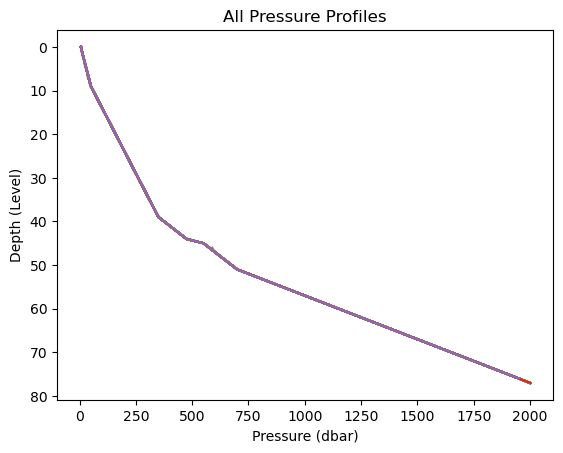

In [9]:
for j in range(T.shape[1]):
    plt.plot(T[:, j], level)

plt.gca().invert_yaxis()
plt.title("All Temperature Profiles")
plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (Level)")
plt.show()


for j in range(S.shape[1]):
    plt.plot(S[:, j], level)

plt.gca().invert_yaxis()
plt.title("All Salinity Profiles")
plt.xlabel("Salinity (psu)")
plt.ylabel("Depth (Level)")
plt.show()


for j in range(P.shape[1]):
    plt.plot(P[:, j], level)

plt.gca().invert_yaxis()
plt.title("All Pressure Profiles")
plt.xlabel("Pressure (dbar)")
plt.ylabel("Depth (Level)")
plt.show()

### 2.5 Now make three similar plot, but show only the mean T, S and P at each depth. Show error bars on each plot using the standard deviations.

In [10]:
T_mean = np.mean(T, axis=1)
T_std  = np.std(T, axis=1)

S_mean = np.mean(S, axis=1)
S_std  = np.std(S, axis=1)

P_mean = np.mean(P, axis=1)
P_std  = np.std(P, axis=1)

print(T_mean.shape, T_std.shape)
print(S_mean.shape, S_std.shape)
print(P_mean.shape, P_std.shape)

(78,) (78,)
(78,) (78,)
(78,) (78,)


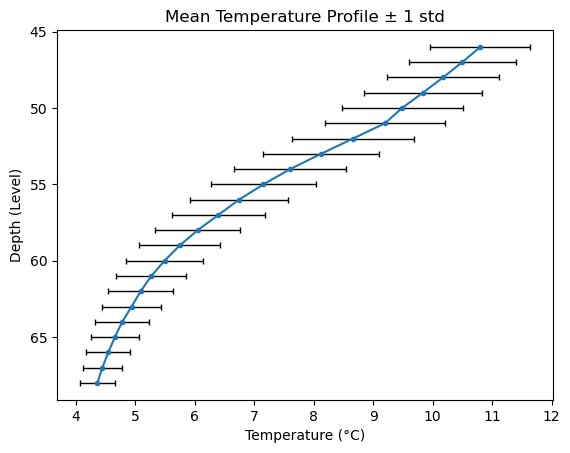

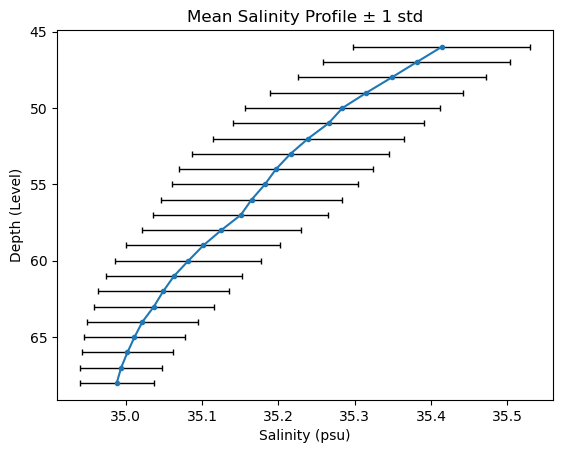

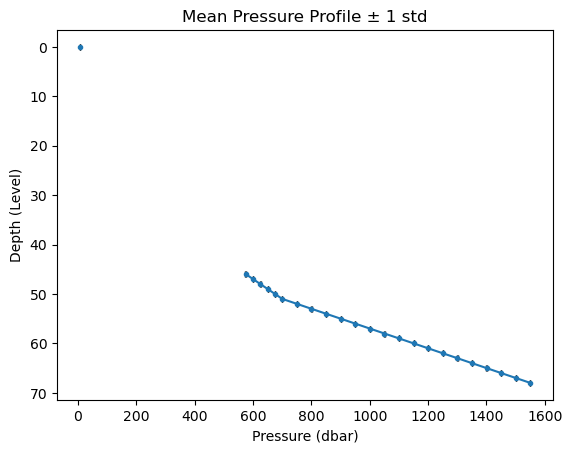

In [11]:
plt.figure()
plt.errorbar(T_mean, level, xerr=T_std, 
             fmt='o-', markersize=3, capsize=2, ecolor='black', elinewidth=1)
plt.gca().invert_yaxis()
plt.title("Mean Temperature Profile ± 1 std")
plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (Level)")
plt.show()

plt.errorbar(S_mean, level, xerr=S_std,
            fmt='o-', markersize=3, capsize=2, ecolor='black', elinewidth=1)
plt.gca().invert_yaxis()
plt.title("Mean Salinity Profile ± 1 std")
plt.xlabel("Salinity (psu)")
plt.ylabel("Depth (Level)")
plt.show()

plt.errorbar(P_mean, level, xerr=P_std,
            fmt='o-', markersize=3, capsize=2, ecolor='black', elinewidth=1)
plt.gca().invert_yaxis()
plt.title("Mean Pressure Profile ± 1 std")
plt.xlabel("Pressure (dbar)")
plt.ylabel("Depth (Level)")
plt.show()

### 2.6 Account For Missing Data

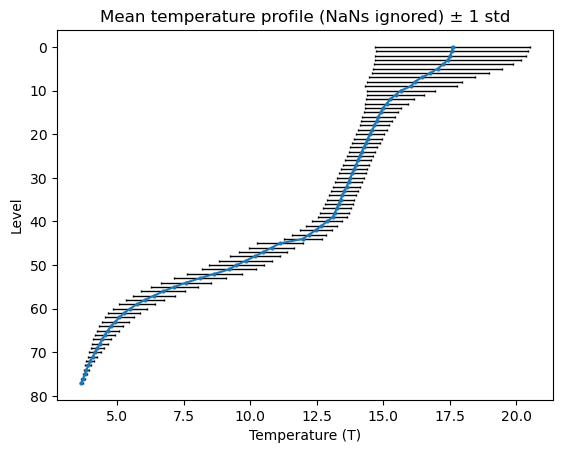

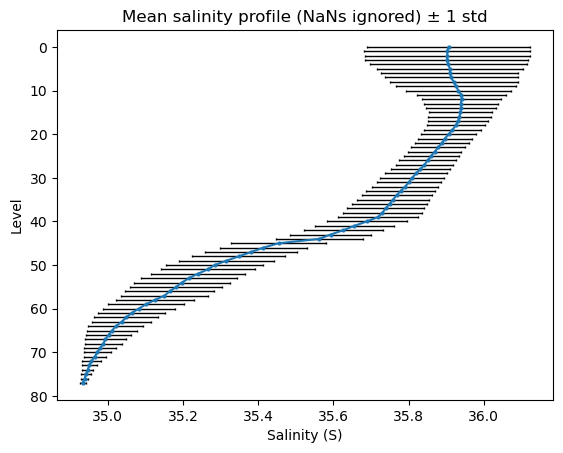

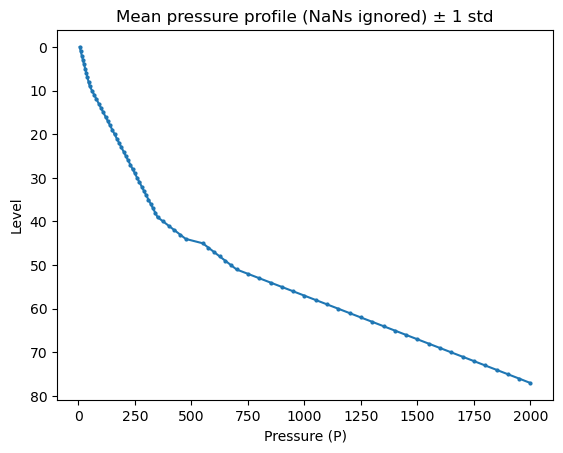

In [12]:
T_mean_nan = np.nanmean(T, axis=1)
T_std_nan  = np.nanstd(T, axis=1)

S_mean_nan = np.nanmean(S, axis=1)
S_std_nan  = np.nanstd(S, axis=1)

P_mean_nan = np.nanmean(P, axis=1)
P_std_nan  = np.nanstd(P, axis=1)

plt.errorbar(T_mean_nan, level, xerr=T_std_nan,
            fmt='o-', markersize=2, capsize=1, ecolor='black', elinewidth=1)
plt.gca().invert_yaxis()
plt.title("Mean temperature profile (NaNs ignored) ± 1 std")
plt.xlabel("Temperature (T)")
plt.ylabel("Level")
plt.show()

plt.errorbar(S_mean_nan, level, xerr=S_std_nan,
            fmt='o-', markersize=2, capsize=1, ecolor='black', elinewidth=1)
plt.gca().invert_yaxis()
plt.title("Mean salinity profile (NaNs ignored) ± 1 std")
plt.xlabel("Salinity (S)")
plt.ylabel("Level")
plt.show()

plt.errorbar(P_mean_nan, level, xerr=P_std_nan,
            fmt='o-', markersize=2, capsize=1, ecolor='black', elinewidth=1)
plt.gca().invert_yaxis()
plt.title("Mean pressure profile (NaNs ignored) ± 1 std")
plt.xlabel("Pressure (P)")
plt.ylabel("Level")
plt.show()

### 2.7 Create a scatter plot of the lon, lat positions of the ARGO float.

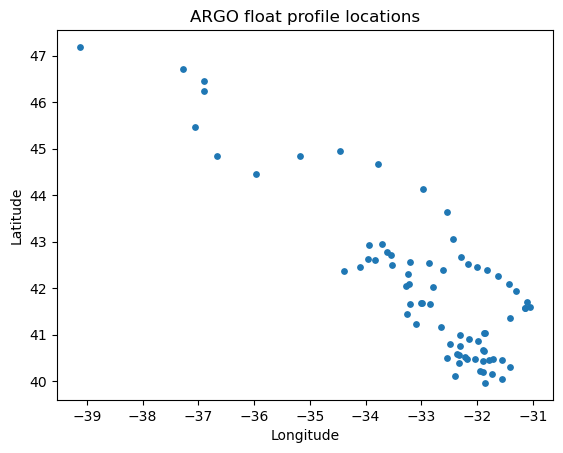

In [13]:
plt.scatter(lon, lat, s=15)
plt.title("ARGO float profile locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()